UNEMPLOYMENT ANALYSIS USING PYTHON

In [18]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

DATA ACQUISITION AND PREPROCESSING

In [19]:
df = pd.read_csv('c:\\Users\\Aalhad Ramteke\\Downloads\\Unemployment in India.csv')

In [20]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [21]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df.shape

(768, 7)

In [23]:
df.isna().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [24]:
df.dropna(inplace=True)

In [25]:
df.isna().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [26]:
df.isnull().any()

Region                                      False
 Date                                       False
 Frequency                                  False
 Estimated Unemployment Rate (%)            False
 Estimated Employed                         False
 Estimated Labour Participation Rate (%)    False
Area                                        False
dtype: bool

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 46.2 KB


In [28]:
df.value_counts()
df.value_counts().drop_duplicates()

Region           Date        Frequency   Estimated Unemployment Rate (%)   Estimated Employed   Estimated Labour Participation Rate (%)  Area 
Andhra Pradesh  31-05-2019  Monthly     3.65                              11999139.0           43.24                                     Rural    1
Name: count, dtype: int64

DATA VISUALIZATION

In [34]:
df['Region'].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
                nan,       'Chandigarh']
Length: 29, dtype: str

In [33]:
df["Area"].unique()

<StringArray>
['Rural', nan, 'Urban']
Length: 3, dtype: str

In [36]:
df.groupby("Area").size()

Area
Rural    359
Urban    381
dtype: int64

UNEMPLOYMENT RATE IN INDIA

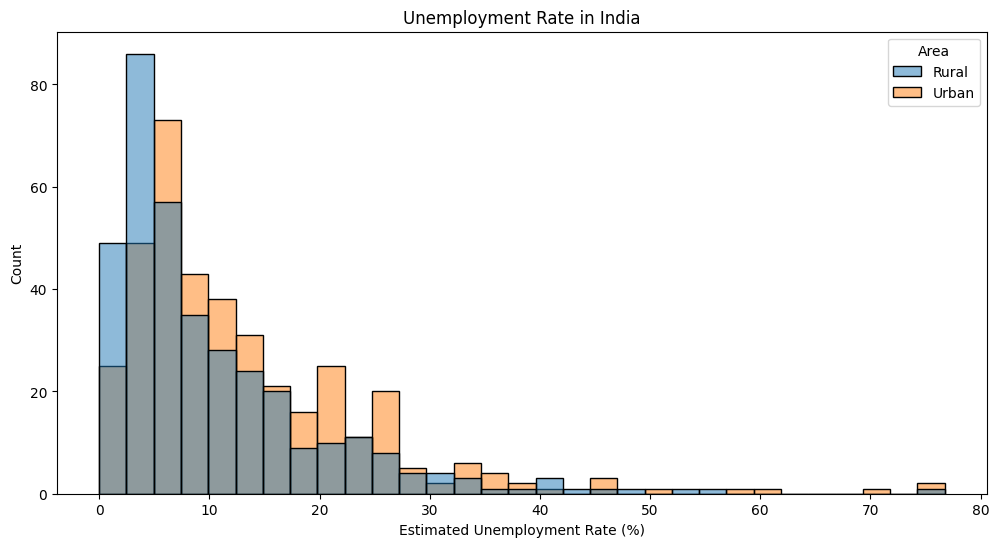

In [49]:
df.columns=["Region","Date","Frequency","Estimated Unemployment Rate (%)","Estimated Employed","Estimated Labour Participation Rate (%)","Area"]
plt.figure(figsize=(12, 6))
plt.title("Unemployment Rate in India")
sns.histplot(x="Estimated Unemployment Rate (%)",hue="Area",data=df)
plt.show()

UNEMPLOYMENT RATE (%) IN INDIA DURING COVID-19 PANDEMIC

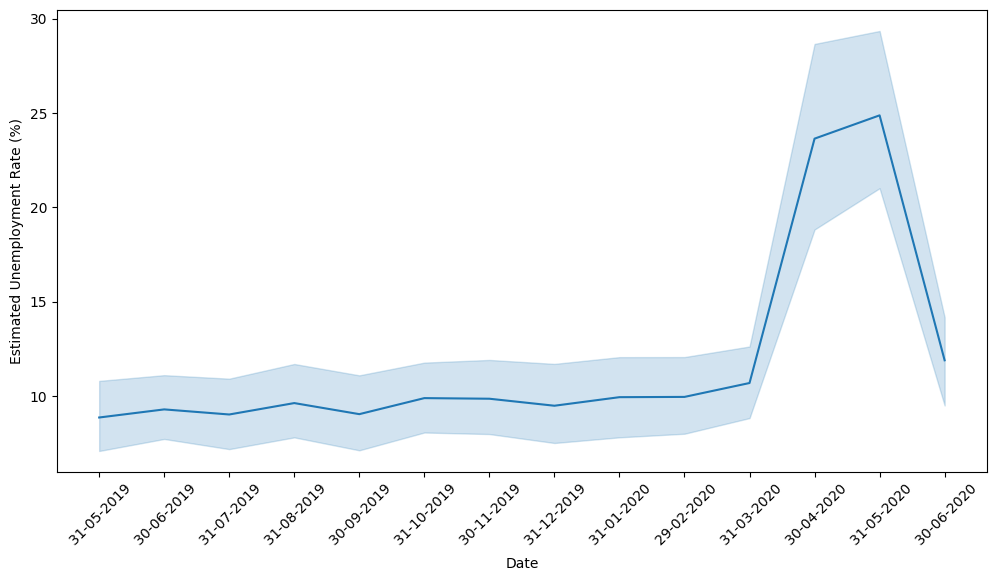

In [42]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

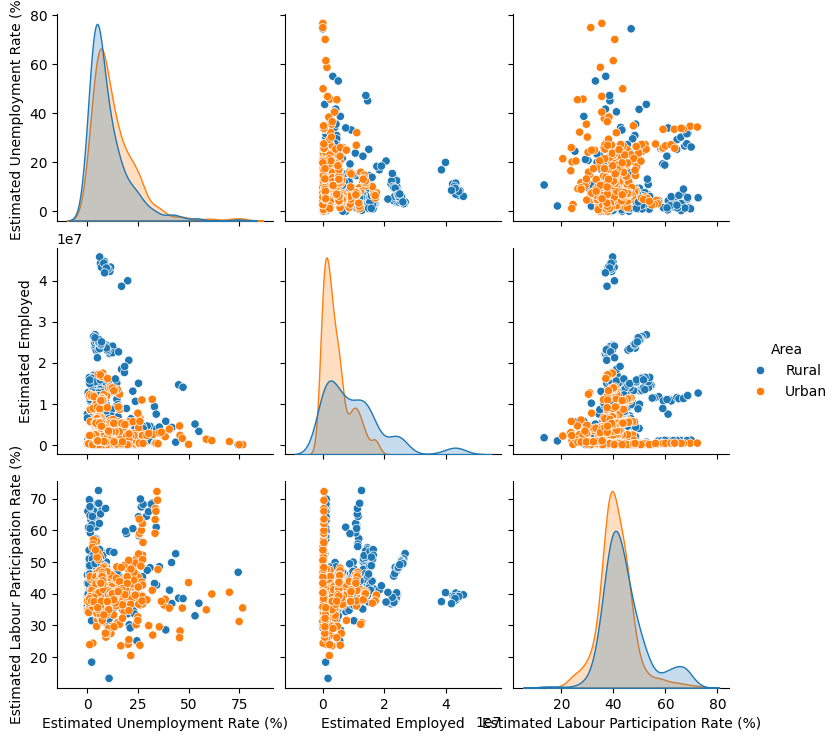

In [48]:
sns.pairplot(df, hue='Area')

OVERALL CHANGE IN UNEMPLOYMENT RATE IN INDIA DURING COVID-19 PANDEMIC

In [56]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df['Month'] = df['Date'].dt.month

In [ ]:
# Filtering data for months 1 to 3 (before lockdown)
before_lock = df[(df['Month'] >= 1) & (df['Month'] <= 3)][['Region', 'Estimated Unemployment Rate (%)']]

# Filtering data for months 3 to 5 (after lockdown)
after_lock = df[(df['Month'] >= 3) & (df['Month'] < 6)][['Region', 'Estimated Unemployment Rate (%)']]

In [59]:
before_lock = before_lock.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index().rename(
    columns={'Estimated Unemployment Rate (%)':'Unemployment Rate before Lock-Down'})

after_lock = after_lock.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index().rename(
    columns={'Estimated Unemployment Rate (%)':'Unemployment Rate after Lock-Down'}) 

In [60]:
before_lock['Percentage Change in Unemployment'] = round((after_lock['Unemployment Rate after Lock-Down'] - before_lock['Unemployment Rate before Lock-Down']) / before_lock['Unemployment Rate before Lock-Down'], 2)

<Axes: xlabel='Percentage Change in Unemployment', ylabel='Region'>

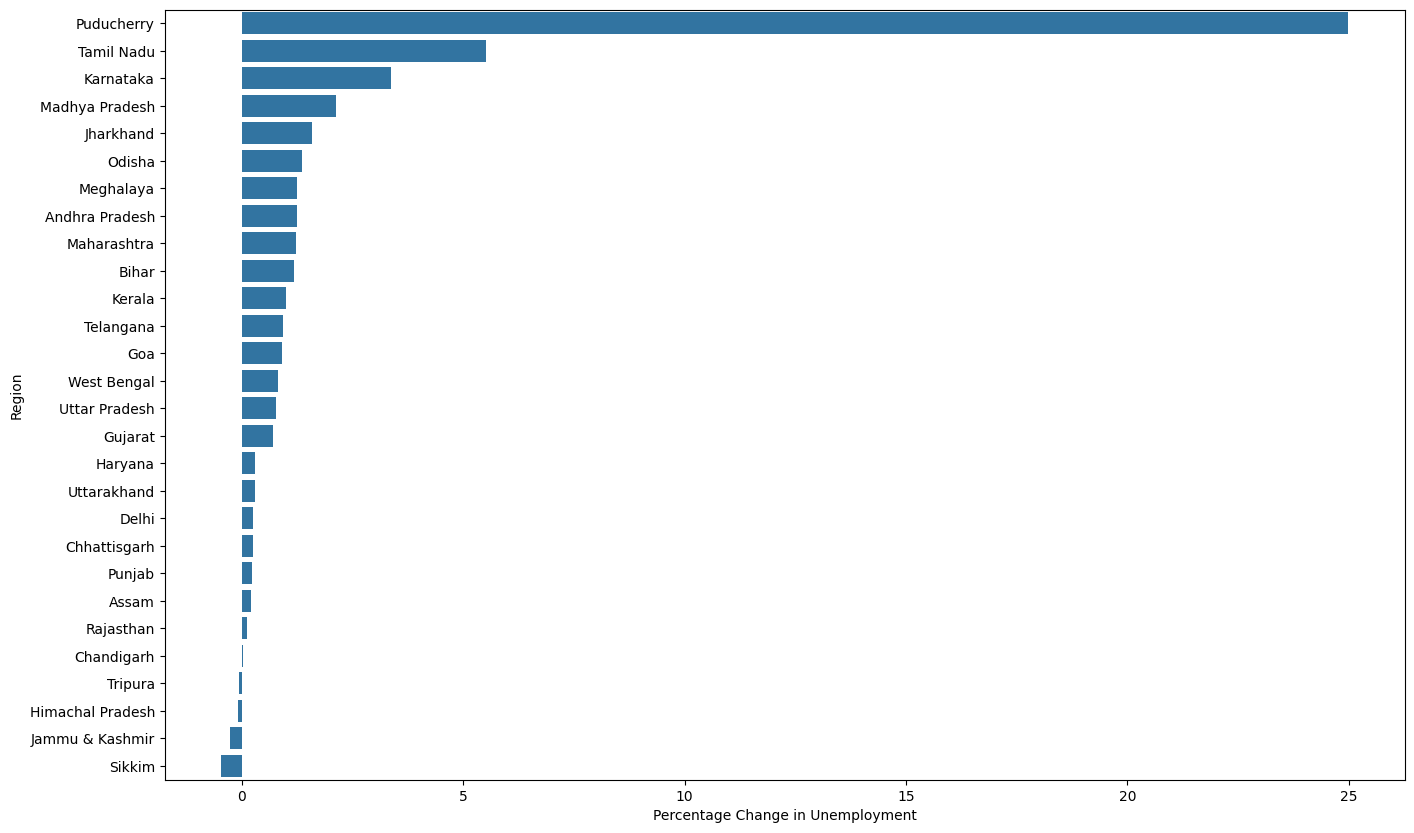

In [61]:
plot_df = before_lock.sort_values('Percentage Change in Unemployment', ascending=False)
plt.figure(figsize=(16, 10))
sns.barplot(data=plot_df, y='Region', x='Percentage Change in Unemployment')

FINAL INSIGHTS

If the percentage change is positive (+X%), it means that unemployment has increased by X% compared to the previous period. 
In other words, more people are unemployed.

If the percentage change is negative (-X%), it means that unemployment has decreased by X% compared to the previous period. 
Fewer people are unemployed.

The magnitude of the percentage change indicates how significant the change is. 
A larger percentage change suggests a more substantial shift in unemployment rates compared to a smaller percentage change.

Puducherry's unemployment rate had been seriously impacted by the lock-down.

Sikkim, Jammu & Kashmir and Himachal Pradesh have negative percentage change. That means these states are not highly impacted by the lock down.